## House Prize Pridiction using Decision Tree Regression 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import pickle

In [2]:
df = pd.read_csv("House Price Prediction Dataset.csv")

### Step 2 Load dataset

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.shape

(2000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [6]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


### Step 3 Data processing (EDA)

In [7]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
# drop ID ,,,because prediction use nhi hota h
df = df.drop("Id", axis=1)

In [10]:
#Encode Categorical Columns
  # Decision Tree don't understand string
df["Location"] = df["Location"].astype("category").cat.codes

df["Condition"] = df["Condition"].astype("category").cat.codes

df["Garage"] = df["Garage"].astype("category").cat.codes

In [11]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,0,0,0,149919
1,4272,5,4,3,1958,0,0,0,424998
2,3592,2,2,3,1938,0,2,0,266746
3,966,4,2,2,1902,2,1,1,244020
4,4926,1,4,2,1975,0,1,1,636056


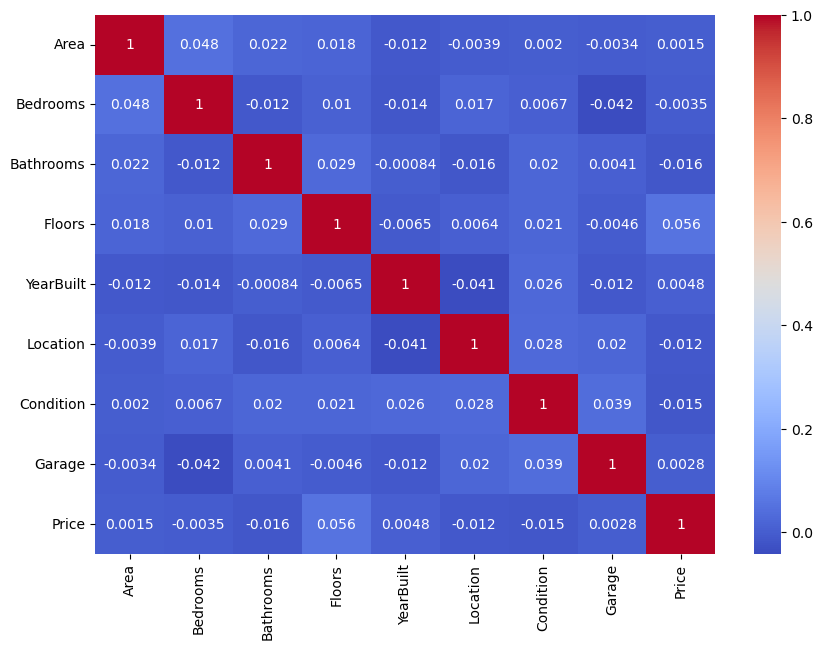

In [12]:
# correlation
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.show()


In [ ]:
# pairplot
sns.pairplot(df)

In [ ]:
# Price Distribution 
sns.histplot(df["Price"],kde=True)
plt.show()

### Step 4 Feature selection 

In [ ]:
X = df.drop("Price",axis=1)

y = df["Price"]

### Step 5 train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42
)

### Step 6 Import Decision Tree

In [ ]:
model = DecisionTreeRegressor(random_state=42)

### Step 7 Train Model

In [ ]:
# learn model training patterns from data
model.fit(X_train,y_train)

### Step 8 Prediction

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

### Step 9 Evaluation

In [ ]:
# R2 score
print("R2 Score :",r2_score(y_test,y_pred))

In [ ]:
#MAE
print("MAE :",mean_absolute_error(y_test,y_pred))

In [ ]:
#MSE
mse = mean_squared_error(y_test,y_pred)

print("MSE :",mse)

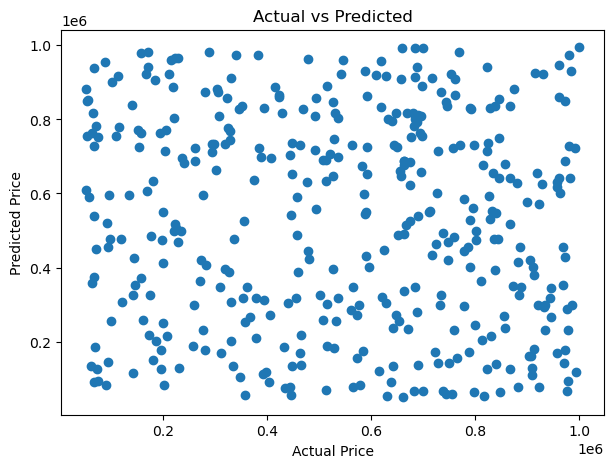

In [27]:
# actual vs predicted
plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

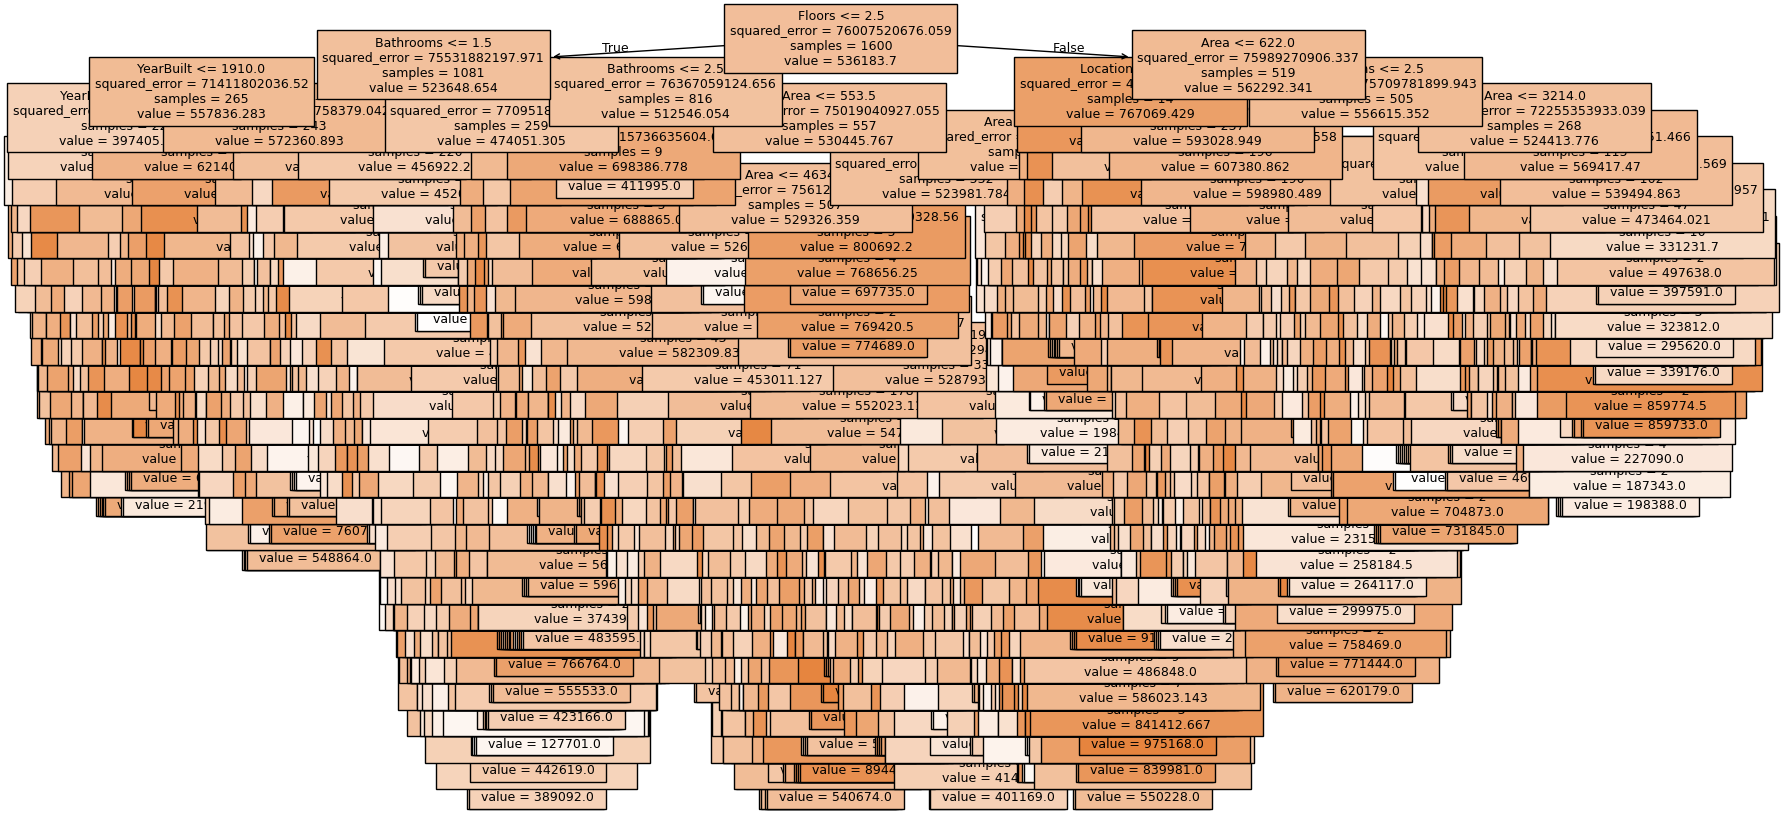

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Example: train a regression tree
# model = DecisionTreeRegressor(max_depth=3).fit(X, y)

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,   # works fine
    filled=True,               # colors nodes by value
    fontsize=9
)

plt.show()



### Step 10 Save Model

In [ ]:
pickle.dump(model,open("house_price_model.pkl","wb")) # save pkl in folder ,house_price_model.pkl
print("run succesfully")